In [6]:
import numpy as np

def prepare_binary_masks(masks):
    # masks shape: (N, 256, 256, 6)
    # sum all cell type channels (0-4), ignore background channel (5)
    binary_mask = masks[..., :5].sum(axis=-1)
    binary_mask = (binary_mask > 0).astype(np.float32)
    return binary_mask  # shape: (N, 256, 256)

In [7]:
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

class PanNukeDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.uint8)
        mask = self.masks[idx].astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.unsqueeze(0)  # add channel dim to mask

# Augmentations
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [8]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [9]:
!pip install segmentation-models-pytorch albumentations -q

In [10]:
!pip install -q datasets huggingface_hub

In [11]:
from datasets import load_dataset
from datasets import concatenate_datasets

dataset = load_dataset("RationAI/PanNuke")

README.md: 0.00B [00:00, ?B/s]

data/fold1-00000-of-00001.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

data/fold2-00000-of-00001.parquet:   0%|          | 0.00/264M [00:00<?, ?B/s]

data/fold3-00000-of-00001.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

Generating fold1 split:   0%|          | 0/2656 [00:00<?, ? examples/s]

Generating fold2 split:   0%|          | 0/2523 [00:00<?, ? examples/s]

Generating fold3 split:   0%|          | 0/2722 [00:00<?, ? examples/s]

In [12]:
# Inspect overall dataset structure
print("Dataset object:")
print(dataset)

print("\nAvailable folds:")
print(dataset.keys())

Dataset object:
DatasetDict({
    fold1: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2656
    })
    fold2: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2523
    })
    fold3: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2722
    })
})

Available folds:
dict_keys(['fold1', 'fold2', 'fold3'])


In [13]:
fold1 = dataset["fold1"]
fold2 = dataset["fold2"]
fold3 = dataset["fold3"]

In [14]:
data = concatenate_datasets([dataset["fold1"], dataset["fold2"], dataset["fold3"]])

In [15]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None  # we apply sigmoid manually
)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [16]:
import torch.nn as nn

class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode='binary')
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, pred, target):
        return (self.bce_weight * self.bce(pred, target) + 
                self.dice_weight * self.dice(pred, target))

In [17]:
print(dataset['fold1'].column_names)

['image', 'instances', 'categories', 'tissue']


In [18]:
def prepare_instance_mask(instances):

    instances = np.array(instances)

    # create empty instance map
    h, w = 256, 256
    instance_map = np.zeros((h, w), dtype=np.int32)

    for i, inst in enumerate(instances):
        instance_map[inst > 0] = i + 1

    return instance_map

In [20]:
import numpy as np
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Training Params
EPOCHS = 20
SUBSET = 1500# reduce dataset for faster training (optional)
BATCH_SIZE = 16
LR = 1e-4

# -------------------------------
# Dataset preparation functions
# -------------------------------

def prepare_image(img):

    img = np.array(img)

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    if img.shape[-1] == 4:
        img = img[..., :3]

    return img


def prepare_instance_mask(instances):

    instances = np.array(instances)

    instance_map = np.zeros((256,256), dtype=np.int32)

    for i, inst in enumerate(instances):
        instance_map[inst > 0] = i + 1

    return instance_map


# -------------------------------
# Transforms
# -------------------------------

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])


# -------------------------------
# Dataset Class
# -------------------------------

class PanNukeDataset(Dataset):
    
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        
        img = self.images[idx]
        mask = self.masks[idx]
        
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]
            
        return img, mask.unsqueeze(0).float()


# -------------------------------
# Load HuggingFace dataset
# -------------------------------

from datasets import load_dataset

dataset = load_dataset("RationAI/PanNuke")

fold_images = []
fold_masks = []

for i in range(1,4):

    fold = dataset[f'fold{i}']

    imgs = []
    msks = []

    for img, inst in zip(fold['image'], fold['instances']):
        
        img = prepare_image(img)
        inst_mask = prepare_instance_mask(inst)

        imgs.append(img)
        msks.append(inst_mask)

    fold_images.append(np.stack(imgs))
    fold_masks.append(np.stack(msks))


# -------------------------------
# Training Loop
# -------------------------------

for fold in range(3):

    print(f"\nTraining Fold {fold+1}")

    val_imgs = fold_images[fold]
    val_msks = fold_masks[fold]

    train_imgs = np.concatenate(
        [fold_images[i] for i in range(3) if i != fold]
    )

    train_msks = np.concatenate(
        [fold_masks[i] for i in range(3) if i != fold]
    )

    # Subset for faster training
    train_imgs = train_imgs[:SUBSET]
    train_msks = train_msks[:SUBSET]

    train_ds = PanNukeDataset(train_imgs, train_msks, train_transform)
    val_ds = PanNukeDataset(val_imgs, val_msks, val_transform)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True
    )

    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE
    )


    # -------------------------------
    # Model (EfficientNet B0)
    # -------------------------------

    model = smp.Unet(
        encoder_name="efficientnet-b0",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    ).to(DEVICE)


    # Loss + Optimizer

    loss_fn = smp.losses.DiceLoss(mode="binary")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR
    )


    # -------------------------------
    # Training
    # -------------------------------

    for epoch in range(EPOCHS):

        model.train()
        train_loss = 0

        loop = tqdm(train_loader)

        for imgs, masks in loop:

            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = model(imgs)

            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            loop.set_description(f"Epoch {epoch+1}")
            loop.set_postfix(loss=loss.item())


        print(f"Epoch {epoch+1} Loss: {train_loss/len(train_loader)}")

Using device: cuda

Training Fold 1


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1: 100%|██████████| 94/94 [00:21<00:00,  4.30it/s, loss=0.877]


Epoch 1 Loss: 0.9154457678186133


...

Epoch 18 Loss: 0.8768672251954992


Epoch 19: 100%|██████████| 94/94 [00:22<00:00,  4.14it/s, loss=0.879]


Epoch 19 Loss: 0.8777698570109428


Epoch 20: 100%|██████████| 94/94 [00:22<00:00,  4.15it/s, loss=0.892]

Epoch 20 Loss: 0.8781009715922335


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6680671..2.6399999].


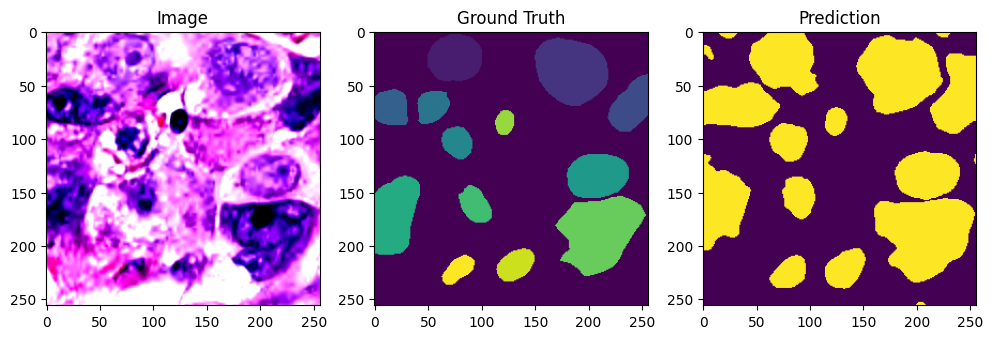

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6155461..2.6399999].


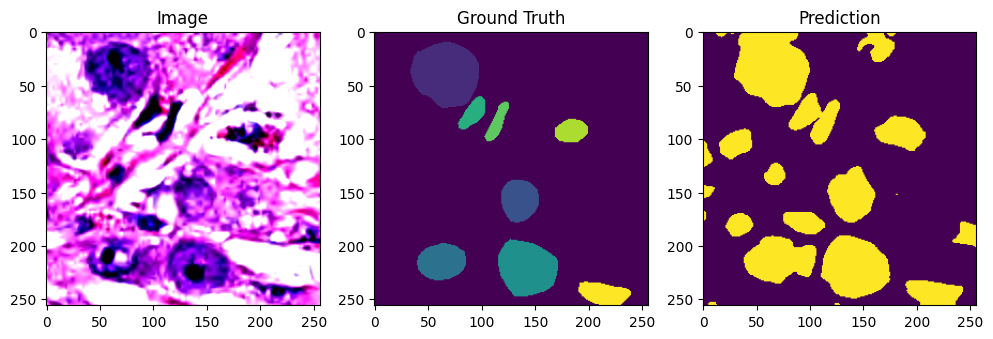

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7556021..2.6399999].


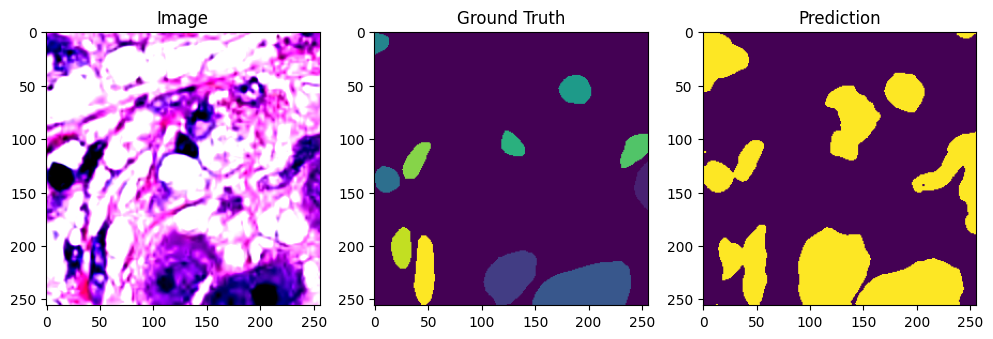

In [21]:
import matplotlib.pyplot as plt

model.eval()

imgs, masks = next(iter(val_loader))

imgs = imgs.to(DEVICE)

with torch.no_grad():
    preds = model(imgs)

preds = torch.sigmoid(preds)
preds = (preds > 0.5).float()

imgs = imgs.cpu()
masks = masks.cpu()
preds = preds.cpu()


for i in range(3):

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(imgs[i].permute(1,2,0))

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(masks[i][0])

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(preds[i][0])

    plt.show()

In [23]:
def dice_score(pred, target):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    target = (target > 0).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2. * intersection + 1e-8) / (union + 1e-8)

In [24]:
dice = dice_score(preds, masks)
print("Dice Score:", dice.item())

Dice Score: 0.76456618309021


In [33]:
device = "cuda"
final_iou = compute_iou(model, val_loader, device)
print("Final IoU:", final_iou)

Final IoU: 8.209077846290924


In [37]:
def compute_iou(model, val_loader, device, threshold=0.5, smooth=1e-6):
    model.eval()

    total_intersection = 0.0
    total_union = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device).float()

            # force GT to binary
            masks = (masks > 0.5).float()

            outputs = model(images)
            preds = torch.sigmoid(outputs)
            preds = (preds > threshold).float()

            intersection = (preds * masks).sum()
            union = preds.sum() + masks.sum() - intersection

            total_intersection += intersection.item()
            total_union += union.item()

    return (total_intersection + smooth) / (total_union + smooth)


In [38]:
iou_score = compute_iou(model, val_loader, device)
print(f"IoU Score: {iou_score:.4f}")


IoU Score: 0.5915
